In [41]:
TRAINING_FINISHED = False
RANDOM_STATE = 42
MAX_ITERATIONS = 5000
MAX_ITERATIONS_SVM = 1000000
TRAINING_SET_SIZE = 0.7
VALIDATION_TEST_SET_RATIO = 0.5

In [42]:
import pandas as pd

data = pd.read_csv('reviews.csv', sep=",",
                   usecols=['rating', 'review_text', 'helpful', 'review_date'])


In [43]:
data = data.dropna(subset=['rating'])
data['helpful'] = data['helpful'].fillna(0)
data['review_text'] = data['review_text'].fillna("")

Repeated characters (e.g., 'AAAA...'): 231 reviews
Repeated words (e.g., 'learning learning...'): 177 reviews
Random word soup (likely bot-generated): 103 reviews
Total noisy reviews: 511 / 6210

:Examples of repeated characters
  Rating 2: "AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA..."
  Rating 1: "5555555555555555555555555555555555555..."
  Rating 3: "qqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqq..."
Examples of repeated words:
  Rating 4: "learning learning learning learning learning learning learni..."
  Rating 1: "truly truly truly truly truly truly truly truly truly truly ..."
  Rating 4: "percentage percentage percentage percentage percentage perce..."
Examples of random word soup:
  Rating 4: "forever controversy workshop lawyer carbon insurance hide glad violate raise goo..."
  Rating 3: "helpful joint strip funding demand split car adviser potential someone beside de..."
  Rating 4: "wine embrace investigate regime stone composition sector guilty fate gender hun

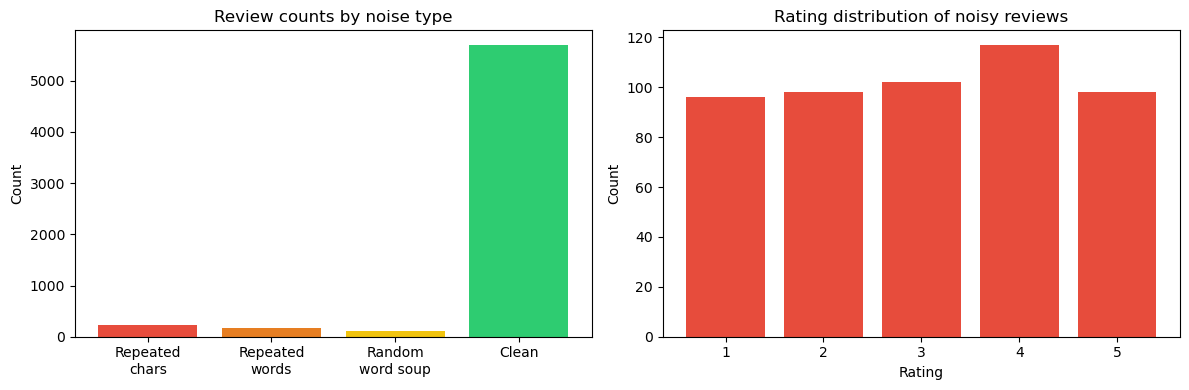

In [57]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS 
import matplotlib.pyplot as plt

def is_repeated_chars(text):
    """Detects text like 'AAAAAAA' or 'hhhhhh' (single char repeated)"""
    if not text or len(text.strip()) == 0:
        return False
    cleaned = text.strip()
    return len(set(cleaned)) <= 2

def is_repeated_words(text):
    """Detects text like 'learning learning learning...'"""
    if not text:
        return False
    words = text.strip().split()
    if len(words) < 5:
        return False
    unique_ratio = len(set(words)) / len(words)
    return unique_ratio < 0.15

def has_low_word_coherence(text):
    """Detects random word chains because of missing stopword ratio..."""
    if not text:
        return False
    words = text.strip().lower().split()
    if len(words) < 15:
        return False

    unique_ratio = len(set(words)) / len(words)
    if unique_ratio <= 0.95:
        return False
    stop_word_ratio = sum(1 for w in words if w in ENGLISH_STOP_WORDS) / len(words)

    # Real Text: ~15–35% Stop-Words. Word-Soup: < 5%
    return stop_word_ratio < 0.08

noisy_chars = data[data['review_text'].apply(is_repeated_chars)]
noisy_words = data[data['review_text'].apply(is_repeated_words)]
noisy_random = data[data['review_text'].apply(has_low_word_coherence)]

print(f"Repeated characters (e.g., 'AAAA...'): {len(noisy_chars)} reviews")
print(f"Repeated words (e.g., 'learning learning...'): {len(noisy_words)} reviews")
print(f"Random word soup (likely bot-generated): {len(noisy_random)} reviews")
print(f"Total noisy reviews: {len(noisy_chars) + len(noisy_words) + len(noisy_random)} / {len(data)}")
print()

print("Examples of repeated characters:")
for _, row in noisy_chars.head(3).iterrows():
    print(f"  Rating {int(row['rating'])}: \"{row['review_text'][:60]}...\"")

print("Examples of repeated words:")
for _, row in noisy_words.head(3).iterrows():
    print(f"  Rating {int(row['rating'])}: \"{row['review_text'][:60]}...\"")

print("Examples of random word soup:")
for _, row in noisy_random.head(3).iterrows():
    print(f"  Rating {int(row['rating'])}: \"{row['review_text'][:80]}...\"")

noise_types = ['Repeated\nchars', 'Repeated\nwords', 'Random\nword soup', 'Clean']
noise_counts = [len(noisy_chars), len(noisy_words), len(noisy_random),
                len(data) - len(noisy_chars) - len(noisy_words) - len(noisy_random)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(noise_types, noise_counts, color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'])
axes[0].set_title('Review counts by noise type')
axes[0].set_ylabel('Count')

noisy_all = set(noisy_chars.index) | set(noisy_words.index) | set(noisy_random.index)
noisy_ratings = data.loc[list(noisy_all), 'rating'].value_counts().sort_index()
axes[1].bar(noisy_ratings.index.astype(int), noisy_ratings.values, color='#e74c3c')
axes[1].set_title('Rating distribution of noisy reviews')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

In [45]:
# lowercase conversion removed: casing can carry sentiment signal (e.g., "GREAT" vs "great")

In [46]:
import contractions

# expand contractions
data['review_text'] = data['review_text'].apply(contractions.fix)

In [47]:
import emoji

# interpret emojis as words
data['review_text'] = data['review_text'].apply(emoji.demojize)

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, hstack

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

data['review_date'] = pd.to_datetime(data['review_date'], format='mixed', dayfirst=False)
data['days_since_first'] = (data['review_date'] - data['review_date'].min()).dt.days

y = data['rating']

In [49]:
from sklearn.model_selection import train_test_split, cross_val_score

# Split raw data first (before vectorization to prevent data leakage)
text_train, text_temp, helpful_train, helpful_temp, date_train, date_temp, y_train, y_temp = train_test_split(
    data['review_text'], data['helpful'], data['days_since_first'], y,
    test_size=1 - TRAINING_SET_SIZE, random_state=RANDOM_STATE, stratify=y
)

text_val, text_test, helpful_val, helpful_test, date_val, date_test, y_validation, y_test = train_test_split(
    text_temp, helpful_temp, date_temp, y_temp,
    test_size=VALIDATION_TEST_SET_RATIO, random_state=RANDOM_STATE, stratify=y_temp
)

# Fit vectorizer on training data only, then transform all sets
X_text_train = tfidf_vectorizer.fit_transform(text_train)
X_text_val = tfidf_vectorizer.transform(text_val)
X_text_test = tfidf_vectorizer.transform(text_test)

# Combine text features with helpful and date columns
X_train = hstack([X_text_train, csr_matrix(helpful_train.values.reshape(-1, 1)), csr_matrix(date_train.values.reshape(-1, 1))])
X_validation = hstack([X_text_val, csr_matrix(helpful_val.values.reshape(-1, 1)), csr_matrix(date_val.values.reshape(-1, 1))])
X_test = hstack([X_text_test, csr_matrix(helpful_test.values.reshape(-1, 1)), csr_matrix(date_test.values.reshape(-1, 1))])

In [50]:
models = []

In [51]:
from sklearn.svm import SVC

# Support Vector Machine model
svc_model = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=MAX_ITERATIONS_SVM
)
svc_model.fit(X_train, y_train)
models.append(svc_model)

/Users/pascalkessler/miniconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [52]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression model
logreg_model = LogisticRegression(class_weight='balanced', max_iter=MAX_ITERATIONS)
logreg_model.fit(X_train, y_train)
models.append(logreg_model)

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    max_depth=9,
    class_weight='balanced',
    n_estimators=300
)
rf_model.fit(X_train, y_train)
models.append(rf_model)

In [54]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd
from scipy import sparse

y_vals = y_train.values if hasattr(y_train, 'values') else np.array(y_train)
class_counts = pd.Series(y_vals).value_counts()
max_count = class_counts.max()

balanced_X, balanced_y = [], []
for cls in class_counts.index:
    mask = y_vals == cls
    X_cls = X_train[mask]
    y_cls = y_vals[mask]
    if len(y_cls) < max_count:
        X_cls, y_cls = resample(X_cls, y_cls, replace=True, n_samples=max_count, random_state=RANDOM_STATE)
    balanced_X.append(X_cls)
    balanced_y.append(y_cls)

if sparse.issparse(X_train):
    X_train_bal = sparse.vstack(balanced_X)
else:
    X_train_bal = np.vstack(balanced_X)
y_train_bal = np.concatenate(balanced_y)

architectures = [
    (64,),
    (128, 64),
    (256, 128),
    (128, 64, 32),
    (128, 128, 64),
    (128, 128, 32),
]
best_score = 0
best_mlp = None

for i, arch in enumerate(architectures):
    print(f"Training architecture #{i} {arch}:")
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        max_iter=MAX_ITERATIONS,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5
    )
    mlp.fit(X_train_bal, y_train_bal)

    val_score = accuracy_score(y_validation, mlp.predict(X_validation))
    print(f"- Validation Accuracy: {val_score:.4f}")

    if val_score > best_score:
        best_score = val_score
        best_mlp = mlp

models.append(best_mlp)

Training architecture #0 (64,):
- Validation Accuracy: 0.4818
Training architecture #1 (128, 64):
- Validation Accuracy: 0.4882
Training architecture #2 (256, 128):
- Validation Accuracy: 0.5118
Training architecture #3 (128, 64, 32):
- Validation Accuracy: 0.5043
Training architecture #4 (128, 128, 64):
- Validation Accuracy: 0.4903
Training architecture #5 (128, 128, 32):
- Validation Accuracy: 0.4732


In [55]:
from sklearn.metrics import accuracy_score, classification_report

# PLOT THAT instead
for i, model in enumerate(models):
    print(f'Evaluate Model #{i}: {type(model).__name__}')
    # SVC uses scaled data
    y_pred = model.predict(X_validation)
    print(f'Accuracy: {accuracy_score(y_validation, y_pred):.4f}')
    print(classification_report(y_validation, y_pred))

    # print("Cross-validation scores: {}".format(cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')))
    # print("Confusion matrix:\n{}".format(confusion_matrix(y_validation, y_pred)))


Evaluate Model #0: SVC
Accuracy: 0.5064
              precision    recall  f1-score   support

           1       0.53      0.63      0.58       237
           2       0.11      0.11      0.11        70
           3       0.15      0.28      0.20        76
           4       0.14      0.14      0.14        95
           5       0.80      0.62      0.70       454

    accuracy                           0.51       932
   macro avg       0.35      0.36      0.34       932
weighted avg       0.56      0.51      0.53       932

Evaluate Model #1: LogisticRegression
Accuracy: 0.4968
              precision    recall  f1-score   support

           1       0.54      0.62      0.57       237
           2       0.15      0.21      0.18        70
           3       0.17      0.33      0.23        76
           4       0.11      0.11      0.11        95
           5       0.81      0.59      0.68       454

    accuracy                           0.50       932
   macro avg       0.36      0.37   

In [56]:
# FINAL SCORING; ONLY USE AFTER FINISHED TRAINING
if not TRAINING_FINISHED:
    print("Skipping final test — set TRAINING_FINISHED = True when ready.")
else:
    for i, model in enumerate(models):
        print(f'Evaluate Model #{i} with type: {type(model).__name__}')
        y_pred = model.predict(X_test)
        print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
        print(classification_report(y_test, y_pred))

Skipping final test — set TRAINING_FINISHED = True when ready.
